<h1 style="text-align: center;"><b>За гранью основ: Спектральная одиссея</b></h1>

**Автор решения:** Павел Орлов

TG: https://t.me/pasha_orlov




<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Beyond the Fundamental: A Spectral Adventure </b></h3>

**Автор**: Ермекова Асель

*P.S.* *На русском перевод емкого и классного названия не получился у меня. Если у вас есть идеи как назвать эту домашку прикольно, пишите в чатике в телеграме ваши предложения русского варианта названия домашки!*

# **Homework: Beyond the Fundamental: A Spectral Adventure**

## **Introduction**

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или А4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## **Submission Instructions**

- Отправьте **Jupyter Notebook** с:
  - Всем кодом
  - Графиками
  - Ответами на вопросы
- Назовите его: `DLS_HW2_Spectrograms_<ваше_имя>.ipynb`

Домашнее задание будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.

# **Load libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import torchaudio
import torch

import warnings
warnings.filterwarnings('ignore')

# **Task 1: Harmonic and Frequency Spectrum Analysis** [6 score]

### **Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.



### **1.1 Load a WAV file** [0.5 score]
- Download file `Vn-ord-A5-pp-1c-N.wav`
- Use `librosa.load(path, sr=None)` to load the audio. Keep the original sampling rate.
- Print the sampling rate and duration.

In [2]:
# !gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O # download violin playing A5: Vn-ord-A5-pp-1c-N.wav

In [3]:
# Example: Load violin A5
audio_path = "Vn-ord-A5-pp-1c-N.wav"
y, sr = librosa.load(audio_path, sr=None)

print(f"Sampling rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

Sampling rate: 44100 Hz
Duration: 7.93 seconds


### **1.2 Compute the Fourier Transform and plot the magnitude spectrum** [1 score]
- Compute the FFT of the entire audio signal. Use `np.fft.rfft` and `np.fft.rfftfreq`.
- Compute absolute values of the magnitude with `np.abs()` and normalize it.
- Plot the magnitude spectrum (only up to Nyquist frequency).
- Label axes: frequency (Hz) vs magnitude.

> 💡 **Tip**: Normalize magnitude by dividing by `len(signal)`.

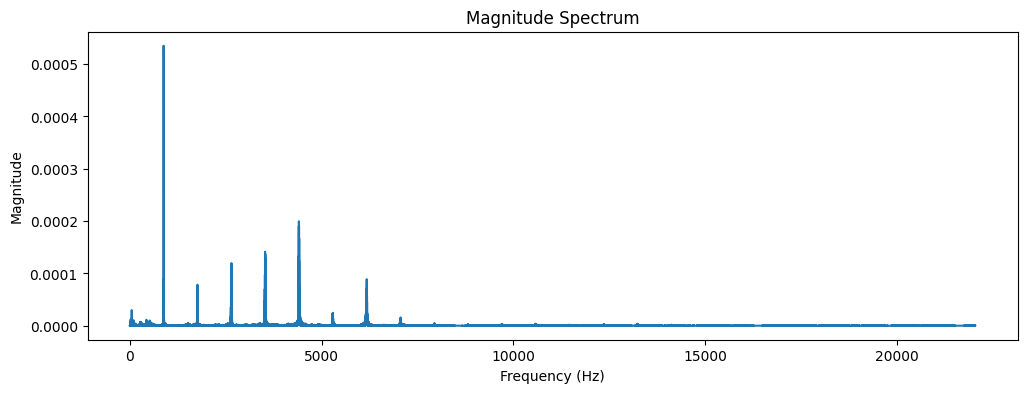

In [4]:
# Compute FFT
spectrum = np.fft.rfft(y)
magnitude = np.abs(spectrum) / len(spectrum)
freqs = np.fft.rfftfreq(len(y), d=1/sr)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum")

plt.show()

### **1.3 Identify and plot harmonics** [0.5 score]
- Find the **fundamental frequency** (f₀) corresponding to the pitch of A5 note (for example, the fundamental frequency for the note A4 is 440 Hz.).
- Calculate harmonics f₀, 2f₀, 3f₀, ..., up to 5000 Hz.
- Plot harmonics as vertical dashed lines and annotate them (e.g., "1st harmonic", "2nd harmonic").

> 📌 **Hint**: You can get theoretical f₀ from `librosa.note_to_hz('A4')`.

Основная частота (f0) для A5: 880.00 Гц


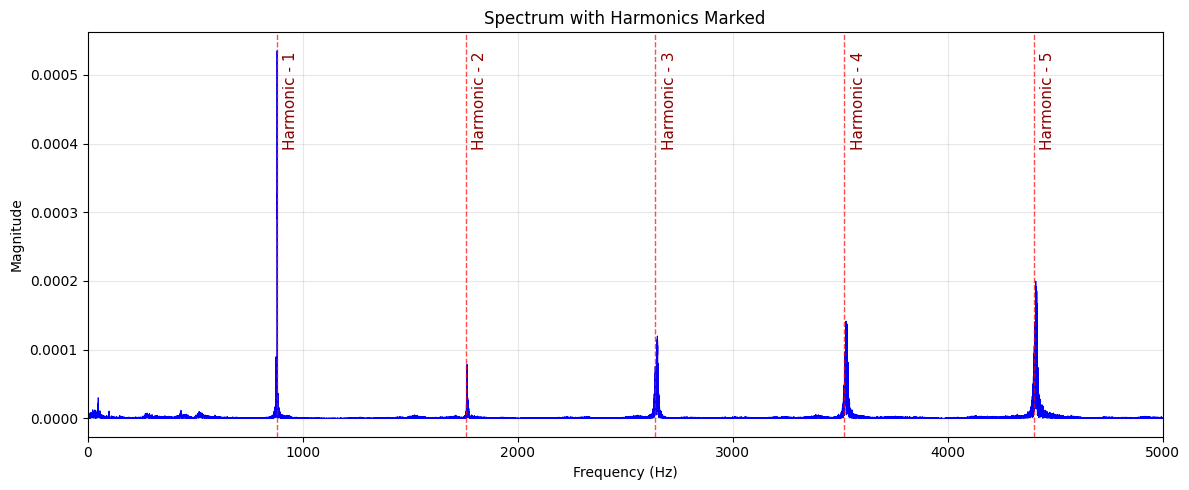

In [5]:
f0 = librosa.note_to_hz('A5')
print(f"Основная частота (f0) для A5: {f0:.2f} Гц")
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n * f0)
    n += 1

# Plot with harmonics marked
plt.figure(figsize=(12, 5))
plt.plot(freqs, magnitude, color='blue', linewidth=0.8)
plt.xlim(0, max_freq)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Spectrum with Harmonics Marked")
plt.grid(alpha=0.3)

for i, h in enumerate(harmonics, start=1):
    plt.axvline(x=h, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.text(h+30, plt.ylim()[1]*0.95, f'Harmonic - {i}',
             rotation=90, verticalalignment='top', fontsize=11, color='darkred')

plt.tight_layout()
plt.show()

### **1.4 Answer: What is the fundamental frequency? What are the amplitudes of the 2nd, 3rd, and 5th harmonics?** [1 score]
- What is the fundamental frequency?
- What are the amplitudes of the 2nd, 3rd, and 5th harmonics?
- Report numerical values (in Hz and amplitude).
- Is the strongest peak always at f₀?

In [6]:
freqs.shape

(174776,)

In [7]:
# Find peaks near harmonic frequencies
def get_harmonic_amplitude(freq, spectrum, freqs):
    idx = np.argmin(np.abs(freqs - freq)) # наиболее близкий индекс к заданной частоте
    half_win = 100 # проверяем на 100 отсечек влево и вправо
    l = max(0, idx - half_win)
    r = min(len(freqs), idx + half_win + 1)
    peak_idx = np.argmax(spectrum[l:r])
    return spectrum[l + peak_idx]

fundamental_amp = get_harmonic_amplitude(f0, magnitude, freqs)
second_harm_amp = get_harmonic_amplitude(2*f0, magnitude, freqs)
third_harm_amp = get_harmonic_amplitude(3*f0, magnitude, freqs)
fifth_harm_amp = get_harmonic_amplitude(5*f0, magnitude, freqs)

print(f"Fundamental frequency (f0): {f0:.1f} Hz")
print(f"Fundamental amplitude: {fundamental_amp:.4f}")
print(f"2nd harmonic amplitude: {second_harm_amp:.4f} ({2*f0})")
print(f"3rd harmonic amplitude: {third_harm_amp:.4f} ({3*f0})")
print(f"5th harmonic amplitude: {fifth_harm_amp:.4f} ({5*f0})")

Fundamental frequency (f0): 880.0 Hz
Fundamental amplitude: 0.0005
2nd harmonic amplitude: 0.0001 (1760.0)
3rd harmonic amplitude: 0.0001 (2640.0)
5th harmonic amplitude: 0.0002 (4400.0)


**Ответы**

Какова основная частота?
> 880.0 Hz

Каковы амплитуды 2-й, 3-й и 5-й гармоник?
Укажите числовые значения (в Гц и амплитуде).
> Соответсвенно : 1760.0=0.0001, 2640.0=0.0001 и 4400.0=0.0002

Всегда ли самый сильный пик находится на частоте f₀?
> Да, для гармонического сигнала **обычно** это так. (но ниже есть исключения для других инструментов)

### **1.5 Repeat for another instruments playing the same pitch** [1 score]
- Choose a different instruments.
- Repeat steps 1.1–1.3.
- **Compare** the two spectra (Violin and another instrument):
  - Are the harmonic amplitudes similar?
  - Which instrument has more high-frequency harmonics?
  - How does this relate to timbre?

In [8]:
# !gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs # Cello: Vc-ord-A5-pp-1c-N.wav
# !gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E # Accordion: Acc-ord-A5-pp-N-N.wav
# !gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI # Flute: Fl-ord-A5-pp-N-N.wav

In [9]:
database = {'Accordion': 'Acc-ord-A5-pp-N-N.wav',
            'Cello': 'Vc-ord-A5-pp-1c-N.wav',
            'Flute': 'Fl-ord-A5-pp-N-N.wav',
            'Violin': 'Vn-ord-A5-pp-1c-N.wav'}

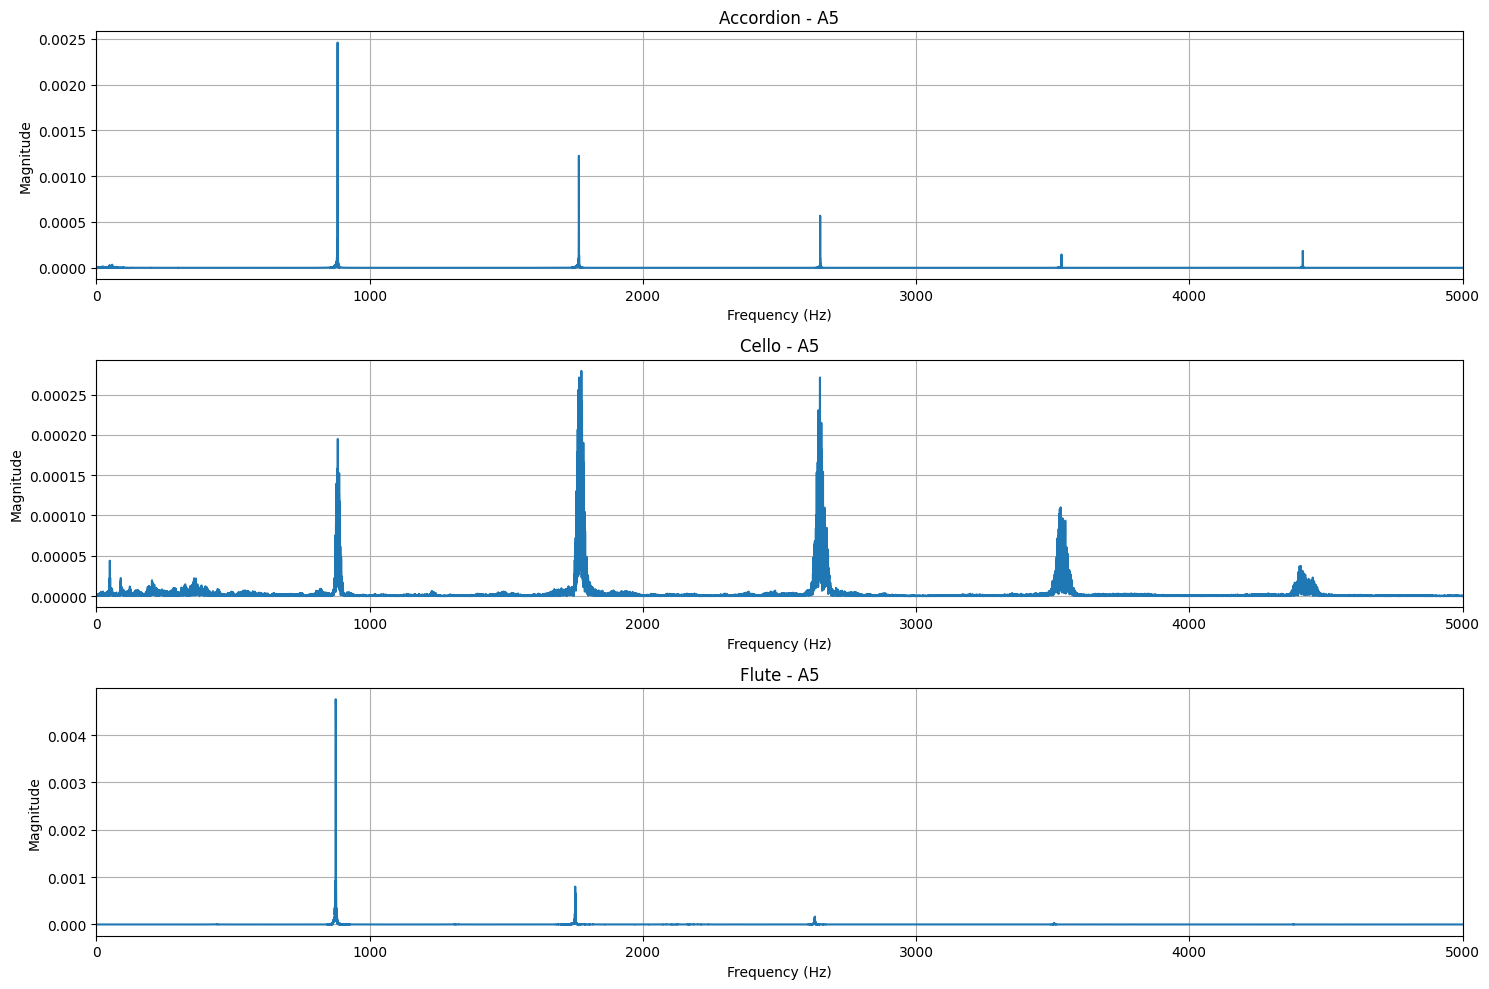

In [10]:
instruments_to_compare = ['Accordion', 'Cello', 'Flute']
plt.figure(figsize=(15, 10))

for i, inst in enumerate(instruments_to_compare):

    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)

    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(Y_inst)

    plt.subplot(3, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - A5')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Analysis:
# - Violin: rich in high harmonics, complex spectrum
# - Flute: mostly fundamental, few weak harmonics
# - Guitar: strong fundamental and lower harmonics, decaying higher harmonics
# This difference in harmonic content IS timbre!

**Ответы:**

Схожи ли амплитуды гармоник?
> Гармоники те же, но амплитуды все таки разные. Например у cello выделяются 2 и 3 гармоники в отличии от других. 

Какой инструмент имеет больше высокочастотных гармоник?
> Cello имеет более сильные высокочастотные гармоники.

Как это связано с тембром?
> Это напрямую связано с тембром. От соотношения гармоник меняется и тембр разных инструментов.

### **1.6 Count significant harmonics** [1 score]
- Define a "significant harmonic" as one with amplitude > 10% of the max amplitude.
- For **Flute** and **Violin** (same pitch), count how many significant harmonics each has.
- Which instrument is "brighter"? Why?

In [11]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1):
    max_amp = np.max(magnitude)
    threshold = threshold_ratio * max_amp

    harmonics = []
    n = 1
    while n * f0 <= max_freq:
        harm_freq = n * f0
        # Ранее уже написали функцию для поиска пика - используем её
        peak_amp = get_harmonic_amplitude(harm_freq, magnitude, freqs)
        if peak_amp > threshold:
            harmonics.append(peak_amp)   # сохраняем амплитуду (можно также сохранять частоту)
        n += 1

    return len(harmonics), harmonics

# Compare Flute and violin
for inst in ['Flute', 'Violin']:
    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(Y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f"{inst.capitalize()}: {count} significant harmonics")

Flute: 2 significant harmonics
Violin: 5 significant harmonics


### **1.7. Simple Instrument Classification** [2 score]
- Use dataset `TinySOL_short` provided below with 3 instruments of the **same pitch** A5.
- **Approach A**: Use raw audio waveforms (flattened) as features → train a Random Forest.
- **Approach B**: Use magnitude spectrum (first 1024 bins) as features → train same model.
- Compare accuracy on a test set.
- **Question**: Why does Approach B perform better?

> 🛠️ Use `sklearn.tree.RandomForestClassifier` and `train_test_split`.

First, download dataset.

In [12]:
# !gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO # download dataset

In [13]:
# df = pd.read_csv("/content/TinySOL_short/TinySOL_short.csv")
df = pd.read_csv("./TinySOL_short/TinySOL_short.csv")

df.head(3)

,Path,Fold,Family,Instrument (abbr.),Instrument (in full),Technique (abbr.),Technique (in full),Pitch,Pitch ID,Dynamics,Dynamics ID,Instance ID,String ID (if applicable),Needed digital retuning
0,TinySOL_short/Strings/Violoncello/ordinario/Vc...,0,Strings,Vc,Cello,ord,ordinario,A5,81,pp,0,0,1.0,False
1,TinySOL_short/Strings/Violoncello/ordinario/Vc...,3,Strings,Vc,Cello,ord,ordinario,A5,81,mf,2,0,1.0,False
2,TinySOL_short/Strings/Violoncello/ordinario/Vc...,4,Strings,Vc,Cello,ord,ordinario,A5,81,ff,4,0,1.0,True


In [14]:
df.shape, df.columns

((15, 14),
 Index(['Path', 'Fold', 'Family', 'Instrument (abbr.)', 'Instrument (in full)',
        'Technique (abbr.)', 'Technique (in full)', 'Pitch', 'Pitch ID',
        'Dynamics', 'Dynamics ID', 'Instance ID', 'String ID (if applicable)',
        'Needed digital retuning'],
       dtype='object'))

In [15]:
df["Instrument (in full)"].value_counts()

Instrument (in full)
Violin    9
Cello     3
Flute     3
Name: count, dtype: int64

In [16]:
df["Pitch"].value_counts()

Pitch
A5    15
Name: count, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

SEED = 42
TEST_SIZE = 0.3 # 30% тест
# Prepare data for 3 instruments, same pitch (A5)
instruments_class = ['Violin', 'Flute', 'Cello']

wave_arrays = []
spec_arrays = []
labels = []

min_len = float('inf')
for path in df['Path']:
    y, sr = librosa.load(path, sr=None)
    min_len = min(min_len, len(y))

for path, instr in zip(df['Path'], df['Instrument (in full)']):
    y, sr = librosa.load(path, sr=None)
    y_cut = y[:min_len]
    wave_arrays.append(y_cut)
    
    # Вычисляем спектр
    spec = np.abs(np.fft.rfft(y_cut)) / len(y_cut) 
    # Берём первые 1024 бина
    if len(spec) >= 1024:
        spec_features = spec[:1024]
    else:
        spec_features = np.pad(spec, (0, 1024 - len(spec)), 'constant')
    spec_arrays.append(spec_features)
    
    labels.append(instr)

X_wave = np.array(wave_arrays)  # форма: (n_samples, min_len)
X_spec = np.array(spec_arrays)  # форма: (n_samples, 1024)
print('X_wave', X_wave.shape, 'X_spec', X_spec.shape)
# Кодируем метки (0,1,2)
le = LabelEncoder()
y_labels = le.fit_transform(labels)

# Split data
# Разделяем на обучающую и тестовую выборки
X_wave_train, X_wave_test, y_train, y_test = train_test_split(
    X_wave, y_labels, test_size=TEST_SIZE, random_state=SEED, stratify=y_labels)
X_spec_train, X_spec_test, y_train_spec, y_test_spec = train_test_split(
    X_spec, y_labels, test_size=TEST_SIZE, random_state=SEED, stratify=y_labels)

# Train classifiers
# raw waveform
clf_wave = RandomForestClassifier(random_state=SEED)
clf_wave.fit(X_wave_train, y_train)
y_pred_wave = clf_wave.predict(X_wave_test)

# magnitude spectrum
clf_spec = RandomForestClassifier(random_state=SEED)
clf_spec.fit(X_spec_train, y_train_spec)
y_pred_spec = clf_spec.predict(X_spec_test)

# Evaluate
acc_wave = accuracy_score(y_test, y_pred_wave)
acc_spec = accuracy_score(y_test_spec, y_pred_spec)

print(f"Accuracy with raw waveforms: {acc_wave:.3f}")
print(f"Accuracy with spectra: {acc_spec:.3f}")

X_wave (15, 258982) X_spec (15, 1024)
Accuracy with raw waveforms: 0.600
Accuracy with spectra: 0.800


**Answer**: 
- Спектр предоставляет более информативные признаки. Там сразу видно, какие частоты какой уровень именют (базовая и гармоники). А именно от их соотношения и зависит тембр инструмента. Поэтому становится проще по тембру предсказать инструмент.
- При использовании спектрограмм мы снижаем размерность: вместо 258982 для спектра 1024 (даже если не обрезать, то размерность будет меньше). Модели проще обучаться.

# **Task 2: Windowing in STFT – Why Not Rectangular?** [10 score]

### **Goal**: Understand spectral leakage and why smooth windows (e.g., Hann) are preferred.

### **2.1 Load a pure sine wave** [0.5 score]
- Generate a 440 Hz sine wave, 1 second long, at 22050 Hz sampling rate.
- Plot the waveform.

$$y = \sin(2 \pi ft)$$

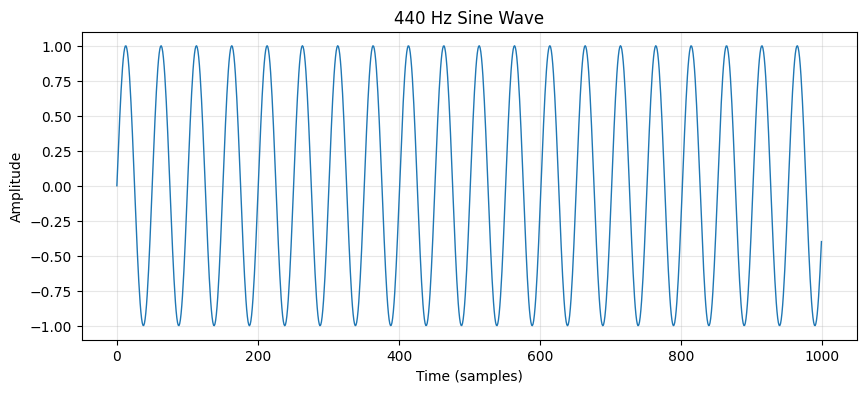

In [18]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2 * np.pi * f0 * t)

# Plot waveform and Show first 1000 samples
plt.figure(figsize=(10, 4))
plt.plot(sine_wave[:1000], linewidth=1)
plt.title("440 Hz Sine Wave")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.show()

### **2.2 Compute STFT with rectangular window** [1 score]
- Use `scipy.signal.stft` with `window='boxcar'` (rectangular), `nperseg=1024`, `noverlap=512`.
- Plot the spectrogram (use `plt.pcolormesh` with dB scale).

> 💡 Convert to dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

In [19]:
from scipy.signal import stft


In [20]:
def compute_stft(sine_wave, sr, window):
    f, t_spec, Zxx = stft(sine_wave, fs=sr, window=window, nperseg=1024, noverlap=512)
    Zxx_dB = 10 * np.log10(np.abs(Zxx) + 1e-10)
    return f, t_spec, Zxx_dB

In [21]:
def plot_spectrogram(t_spec, f, Zxx_dB, win_name, y_max=1000):
    plt.figure(figsize=(14, 6))
    plt.pcolormesh(t_spec, f, Zxx_dB, shading='auto', cmap='viridis')
    plt.colorbar(label='Magnitude (dB)')
    plt.title(f'STFT Spectrogram ({win_name} window)')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    if y_max is not None:
        plt.ylim(0, y_max) 
    plt.show()    

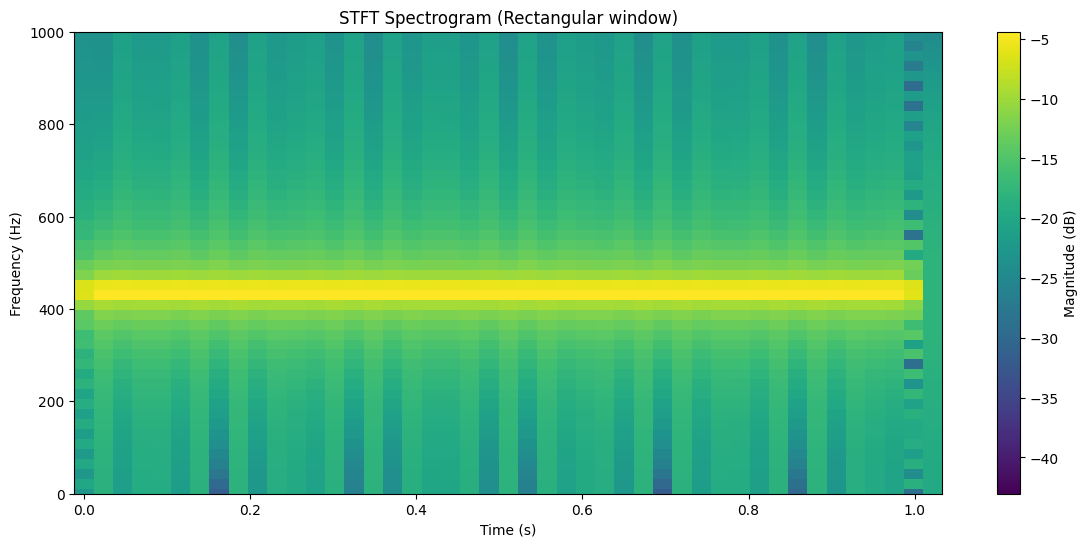

In [22]:

# Compute STFT with rectangular window
f, t_spec, Zxx_dB = compute_stft(sine_wave, sr, window='boxcar')
# Plot spectrogram
plot_spectrogram(t_spec, f, Zxx_dB, win_name='Rectangular')

### **2.3 Compute STFT with Hann window** [1 score]
- Repeat with `window='hann'`.
- Plot the spectrogram.

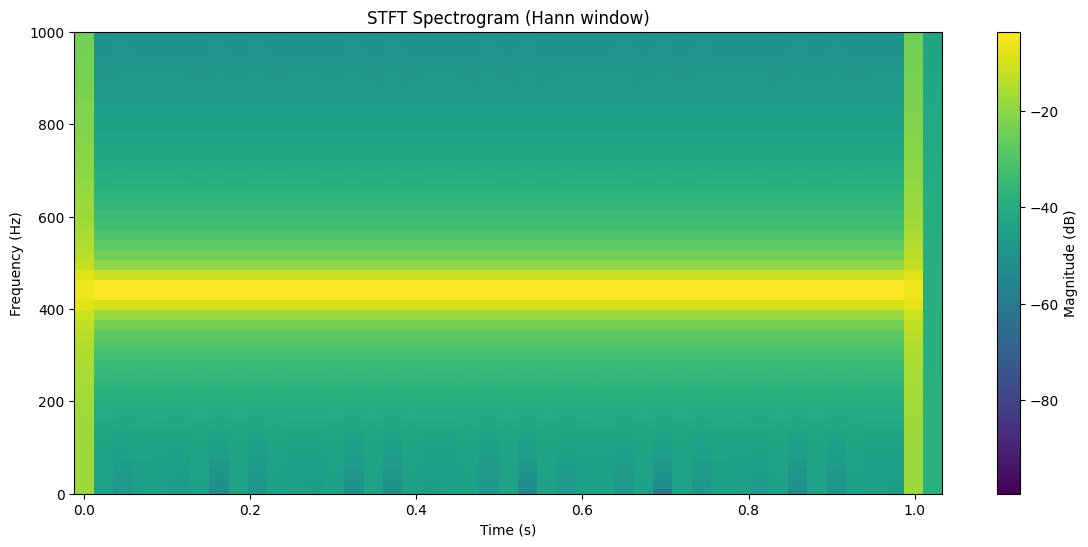

In [23]:
# Compute STFT with hann window
f, t_spec, Zxx_dB = compute_stft(sine_wave, sr, window='hann')
# Plot spectrogram
plot_spectrogram(t_spec, f, Zxx_dB, win_name='Hann')

### **2.4 Compare the two spectrograms** [1.5 score]
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? [0.5 score]
- **Question**: Is the main lobe wider or narrower with Hann? [0.5 score]
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? [0.5 score]

Answers to questions:
- в случае "rectangular" мы видим доп. вертикальные полосы, которые показывают некоторое растекание энергии по частотам. (не учитываем края слева и справа, а речь про основную площадь)
- в случае "Hann" основная частота немного шире, чем у "rectangular"
- в "Hann" спектрограмма в целом более чистая. Мы видим что энергия в основном в полосе 440.
     

### **2.5 Try a signal with two close frequencies** [2 score]
- Generate two sine waves: 440 Hz and 460 Hz.
- Repeat 2.2 and 2.3.
- **Question**: Can you distinguish the two tones with rectangular window? With Hann?


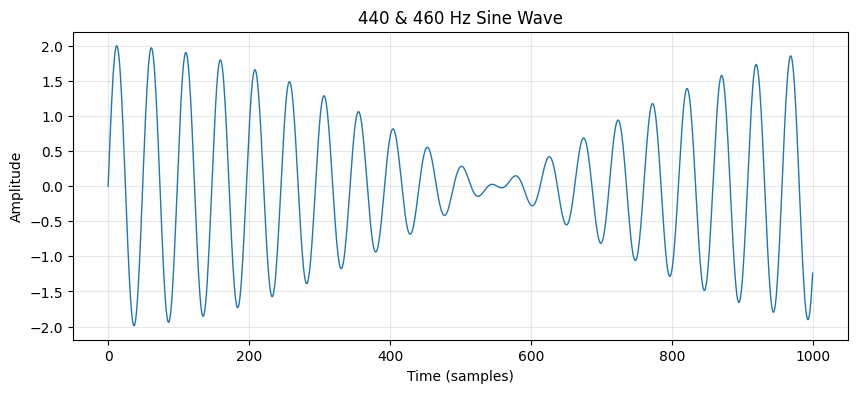

In [24]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

f1 = 440
f2 = 460
sine_wave_2 = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Plot waveform and Show first 1000 samples
plt.figure(figsize=(10, 4))
plt.plot(sine_wave_2[:1000], linewidth=1)
plt.title("440 & 460 Hz Sine Wave")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.show()

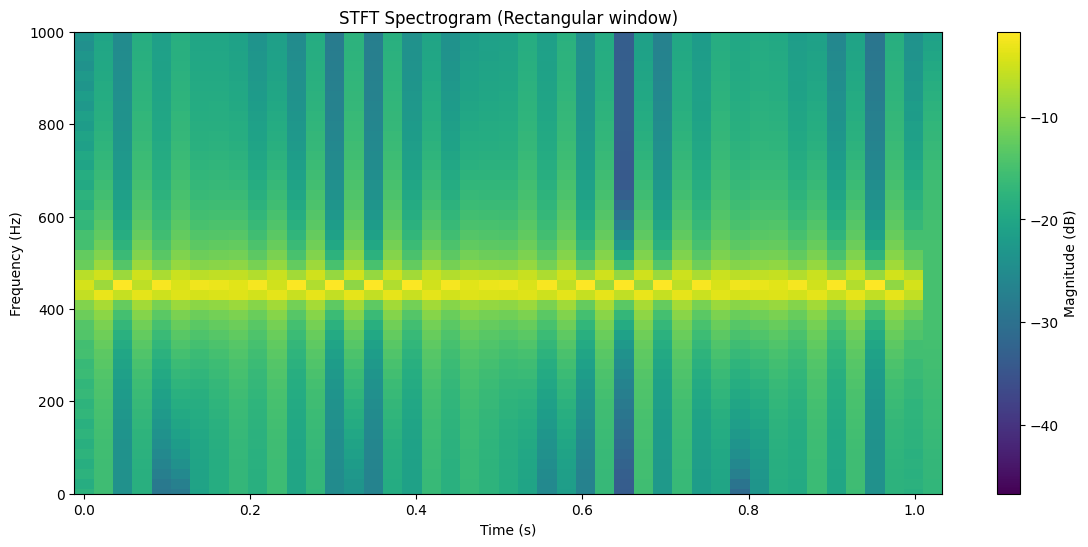

In [25]:
# Прямоугольное окно
f_box, t_box, Zxx_box_dB = compute_stft(sine_wave_2, sr, 'boxcar')
plot_spectrogram(t_box, f_box, Zxx_box_dB, 'Rectangular')

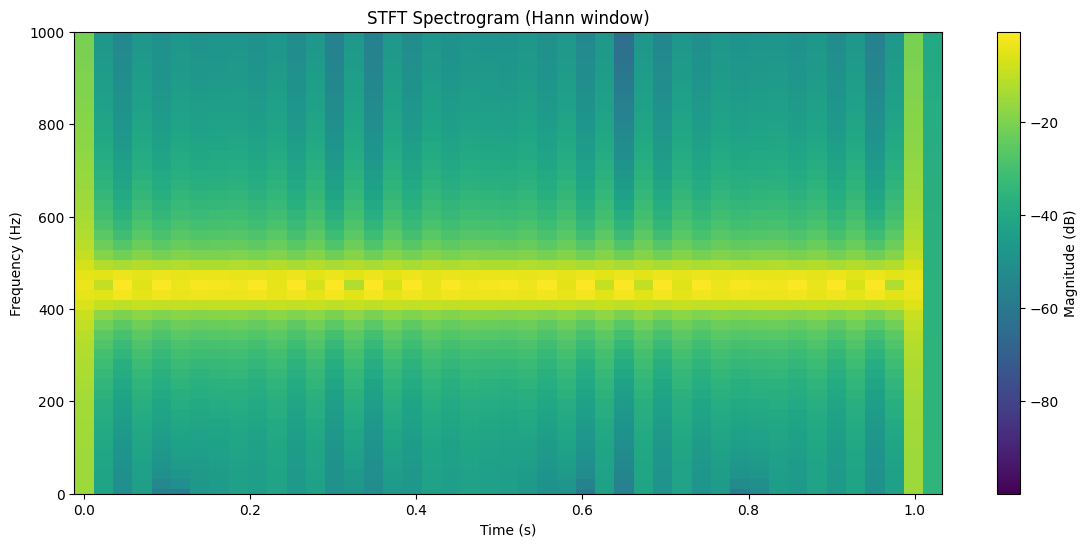

In [26]:
# Окно Ханна
f_hann, t_hann, Zxx_hann_dB = compute_stft(sine_wave_2, sr, 'hann')
plot_spectrogram(t_hann, f_hann, Zxx_hann_dB, 'Hann')

**Answer**: Такие близкие частоты плохо различаются на спектрограмме. По сути они сливаются. Но для Rectangular горизонтальные более четкие

### **2.6 Analyze a real instrument note** [1 score]
- Load a flute note (A5).
- Compute spectrograms with rectangular and Hann windows.
- **Question**: Does rectangular window create "smearing" or artificial frequencies? [0.5 score]
- **Question**: Which spectrogram better reflects the true harmonic structure? [0.5 score]

In [27]:
# Load flute note A5
row = df[(df['Instrument (in full)'] == "Flute") & (df['Pitch'] == 'A5')].iloc[0]
y_inst, sr_inst = librosa.load(row.Path, sr=None)

# Compute STFT with rectangular and hann window
# Plot spectrograms

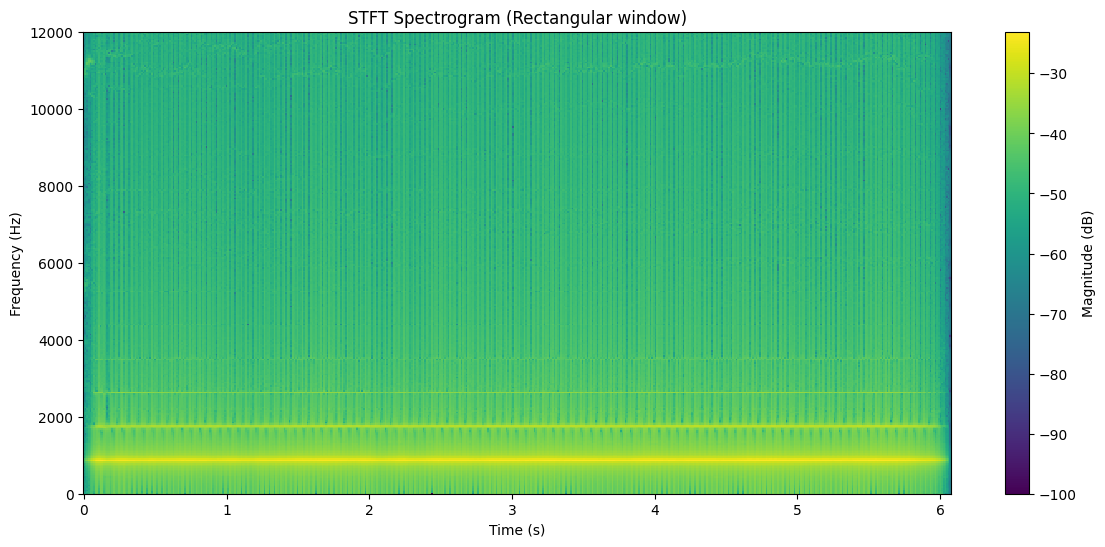

In [28]:
# Прямоугольное окно
f_box, t_box, Zxx_box_dB = compute_stft(y_inst, sr_inst, 'boxcar')
plot_spectrogram(t_box, f_box, Zxx_box_dB, 'Rectangular',y_max=12000)

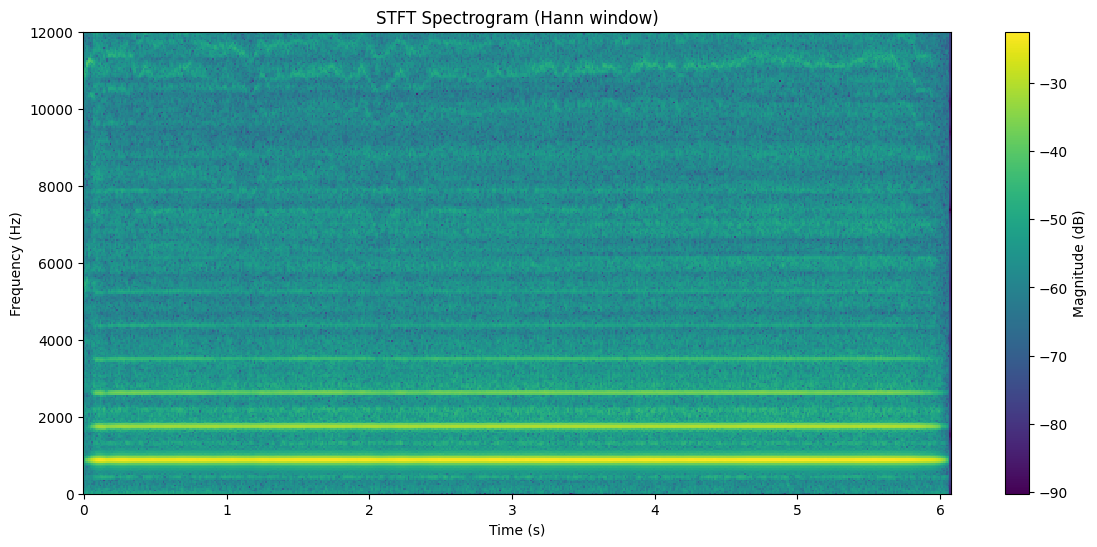

In [29]:
# Окно Ханна
f_hann, t_hann, Zxx_hann_dB = compute_stft(y_inst, sr_inst, 'hann')
plot_spectrogram(t_hann, f_hann, Zxx_hann_dB, 'Hann',y_max=12000)

**Answer**: 

Вопрос: Создает ли прямоугольное окно «размытие» или искусственные частоты? [0,5 балла]
> Для Rectangular видны вертикальные линии. Что означает некое размытие сигнала по частотам. Для варианта Hann их нету.

Вопрос: Какая спектрограмма лучше отражает истинную гармоническую структуру? [0,5 балла]
> Вариант Hann лучше отражает гармоническую структуру. Тут более четкие горизонтальные линии частот.

### **2.7 Conclusion** [3 score]
- Write 3–4 sentences explaining:
  - What is **spectral leakage**?
  - Why does rectangular window cause it?
  - Why is a smooth (bell-shaped) window better for audio analysis?

**Answer**: 

Что такое **спектральная утечка**?
> Явление, когда энергия одной частоты как бы "растекается" на соседние частоты.

Почему прямоугольное окно вызывает её?
> Потому что оно резко обрезает сигнал до нуля на границах. При преобразовании Фурье это равно умножению на прямоугольную функцию. А ее спектр имеет большие боковые лепестки, которые и переносят энергию на другие частоты.

Почему гладкое (колоколообразное) окно лучше подходит для анализа звука?
> Оно плавно сводит сигнал к нулю на краях. Это подавляет боковые лепестки в частотной области и уменьшает спектральную утечку.

# **Task 3: Implement Your Own Mel-Spectrogram Transform** [5 score]

### **Goal**: Understand how Mel-scale warping works by implementing it manually.

### **3.1 Load an audio file** [0.5 score]
- Pick any `.wav` from the dataset.
- Load with `librosa.load(..., sr=22050)`.

In [30]:
# Load audio
sample = df.iloc[0]
y, sr = librosa.load(sample.Path, sr=22050)

### **3.2 Compute STFT** [0.5 score]
- Use `librosa.stft` with `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Compute power spectrogram: `S = np.abs(stft_result) ** 2`.

In [31]:
n_fft=2048
hop_length=512
n_mels=128

In [32]:
# Compute STFT
stft_result = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
S = np.abs(stft_result) ** 2

### **3.3 Create Mel filterbank manually** [2 score]
- Number of Mel bands: `n_mels = 128`.
- Frequency range: 0 to `sr/2`.
- Steps:
  1. Convert Hz to Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Create `n_mels + 2` equally spaced points in Mel scale.
  3. Convert back to Hz.
  4. Build triangular filters (each filter overlaps with neighbors).
- Output: a matrix `mel_basis` of shape `(n_mels, n_fft//2 + 1)`.

> 📚 Reference: [Librosa mel filterbank docs](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

In [33]:
def hz_to_mel(frequencies):
    """Convert Hz to Mel scale"""
    return 2595 * np.log10(1 + np.array(frequencies) / 700)

def mel_to_hz(mels):
    """Convert Mel to Hz scale"""
    return 700 * (10**(np.array(mels) / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """Create Mel filterbank manually"""

    # Frequency bins
    n_freqs = n_fft // 2 + 1
    linear_freqs = np.linspace(0, sr/2, n_freqs)

    if fmax is None:
        fmax = sr / 2
    # Mel points
    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    # Create filterbank
    filterbank = np.zeros((n_mels, n_freqs))

    for m in range(n_mels):
        # Triangle vertices
        left = hz_points[m]
        center = hz_points[m + 1]
        right = hz_points[m + 2]

        idx = np.where((linear_freqs >= left) & (linear_freqs <= right))[0]
        freqs = linear_freqs[idx]
        weights = np.minimum((freqs - left) / (center - left), (right - freqs) / (right - center))
        filterbank[m, idx] = weights

    return filterbank

# Create filterbank
mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels=n_mels)

### **3.4 Apply filterbank to power spectrogram** [0.5 score]
- Compute: `mel_spec_manual = np.dot(mel_basis, S)`

In [34]:
# Apply manual filterbank
mel_spec_manual = np.dot(mel_basis_manual, S)

### **3.5 Compute Mel-spectrogram using librosa** [0.5 score]
- Use `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

In [35]:
# Librosa version
mel_spec_librosa = librosa.feature.melspectrogram(
    y=y, sr=sr, 
    n_fft=n_fft, 
    hop_length=hop_length, 
    n_mels=n_mels,
    htk=True,
    norm=None,
)

### **3.6 Compare and validate** [1 score]
- Use `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- If not close, debug your filterbank.
- Plot both Mel-spectrograms side by side (in dB scale).
- **Question**: Are they visually identical?

In [36]:
def plot_comparison(mel_1,title_1,mel_2,title_2):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    librosa.display.specshow(
        librosa.power_to_db(mel_1, ref=np.max),
        sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax1
    )
    ax1.set_title(title_1)
    
    librosa.display.specshow(
        librosa.power_to_db(mel_2, ref=np.max),
        sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax2
    )
    ax2.set_title(title_2)
    
    plt.tight_layout()
    plt.show()    

Manual and librosa implementations match (atol=1e-5): True


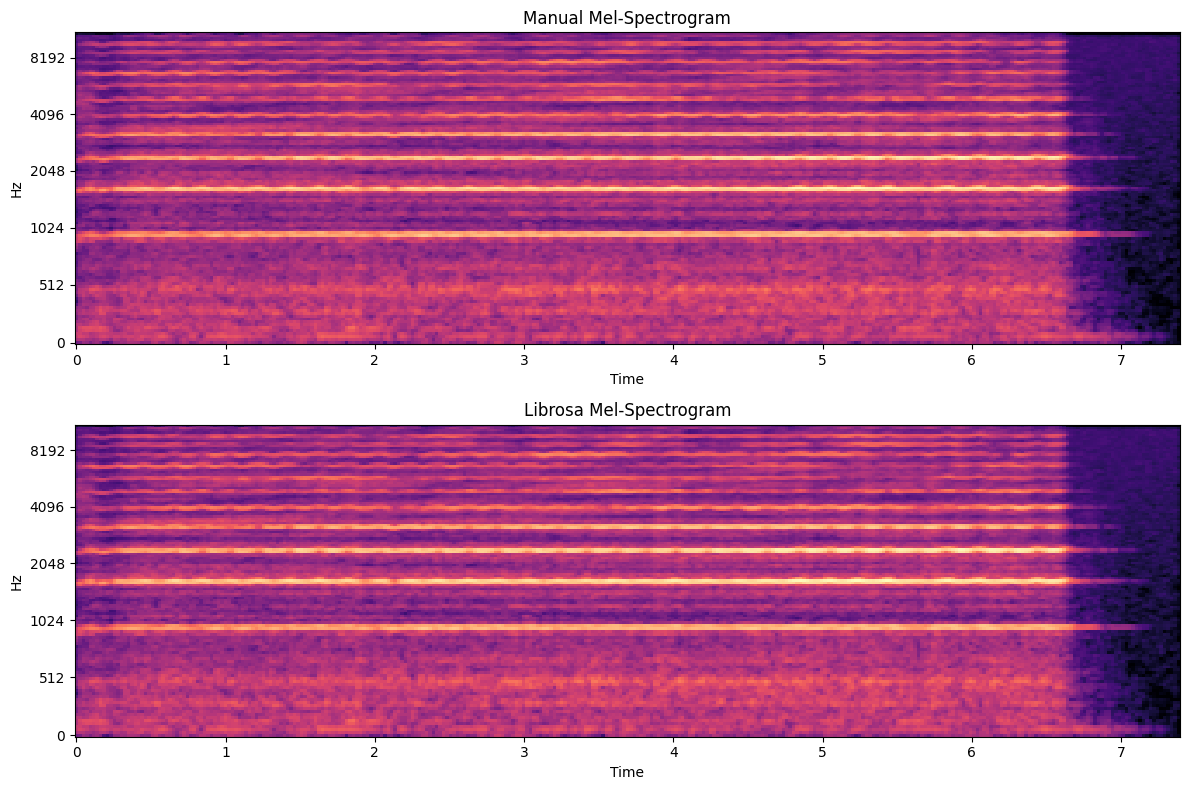

In [37]:
# Compare
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)
print(f"Manual and librosa implementations match (atol=1e-5): {are_close}")

# Plot comparison
plot_comparison(mel_spec_manual,'Manual Mel-Spectrogram',mel_spec_librosa,'Librosa Mel-Spectrogram')

### **3.7 Bonus: Try with torchaudio**
- Repeat using `torchaudio.transforms.MelSpectrogram`.
- Compare with your implementation.

Manual and torchaudio implementations match (atol=1e-5): True


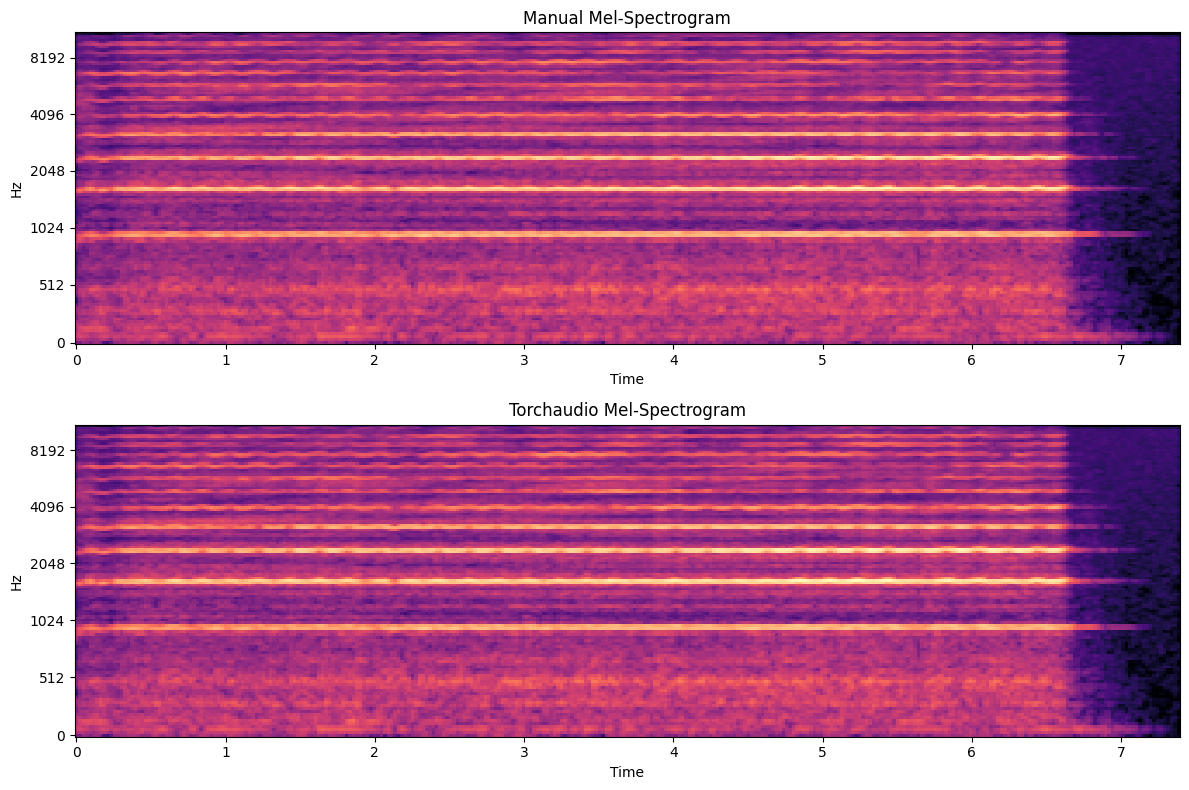

In [38]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=n_fft,                # по умолчанию равно n_fft
    window_fn=torch.hann_window,     # окно Ханна
    n_mels=n_mels,
    mel_scale='htk',                 # используем HTK-формулу
    norm=None,                       # без нормировки фильтров
    center=True,                     # центрирование окон (как в librosa по умолчанию)
    power=2.0,                       # мощность спектра
    pad_mode='constant',
)

y_tensor = torch.tensor(y, dtype=torch.float32)
mel_spec_torch = mel_transform(y_tensor).numpy()

# Note: torchaudio uses different scaling, so direct comparison needs care
are_close = np.allclose(mel_spec_manual, mel_spec_torch, atol=1e-5)
print(f"Manual and torchaudio implementations match (atol=1e-5): {are_close}")

plot_comparison(mel_spec_manual,'Manual Mel-Spectrogram',mel_spec_torch,'Torchaudio Mel-Spectrogram')
